# Donut Fine-Tuned Model Test — kardi (로컬 입력)

`donut_CORD_v2_fine_tunned_test.ipynb` 의 변형: 입력을 **`test_data/test_title_01.png`** 로 처리한다.
커널: **kardi_env**.

> **🔹 역할** — Python/PyTorch/CUDA 환경 및 GPU 정보 출력

In [1]:
import sys, torch
print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Python: 3.10.19 (main, Oct 21 2025, 16:38:01) [GCC 11.2.0]
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10


> **🔹 역할** — 필요 라이브러리(transformers, PIL, torch, matplotlib 등) import

In [2]:
from transformers import DonutProcessor, VisionEncoderDecoderModel
from transformers.utils import logging as hf_logging
hf_logging.disable_progress_bar()

from PIL import Image
import torch, json, re
import matplotlib.pyplot as plt
import matplotlib as mpl

## Base Model vs Fine-tuned Model

### Base Model (`donut-base`)
대량의 문서 이미지로 **일반적인 패턴**을 학습한 모델

모델 페이지: https://huggingface.co/naver-clova-ix/donut-base

| 항목 | 내용 |
|------|------|
| 학습 데이터 | IIT-CDIP (1100만 장의 다양한 문서 이미지) |
| 학습 목표 | 이미지에서 텍스트를 읽는 능력 자체를 익힘 |
| 결과 | 문서를 "보고 이해"할 수 있지만 특정 태스크는 모름 |

### Fine-tuned Model (`donut-base-finetuned-cord-v2`)
Huggingface 데이터셋 다운로드 : https://huggingface.co/datasets/naver-clova-ix/cord-v2

Base Model을 출발점으로, **특정 태스크 데이터**로 추가 학습한 모델

| 항목 | 내용 |
|------|------|
| 학습 데이터 | CORD-v2 (영수증 800장 + 정답 JSON) |
| 학습 목표 | 영수증 → `gt_parse` JSON 구조로 변환 |
| 결과 | 영수증 파싱에 특화된 능력 보유 |

### 비유

```
Base Model   = 대학 졸업생  (읽기·이해력은 갖춤, 전문 업무는 아직 모름)
Fine-tuning  = 입사 후 실무 교육  (영수증 처리 업무만 집중 훈련)
Fine-tuned   = 영수증 처리 전문 직원  (영수증 → JSON 즉시 변환 가능)
```

### 학습 흐름

```
[Base Model 사전학습]
대용량 문서 → 일반 표현 학습
        ↓
[Fine-tuning]
CORD-v2 영수증 800장 + 정답 JSON → 태스크 특화 학습
        ↓
[Fine-tuned Model]
영수증 이미지 + <s_cord-v2> 태스크 토큰 → JSON 출력
```

> **🔹 역할** — CORD-v2 파인튜닝 Donut 모델/프로세서 로드 후 GPU로 이동·추론 모드 설정

In [4]:
model_name = "naver-clova-ix/donut-base-finetuned-cord-v2"

# DonutProcessor: 이미지 전처리(resize, normalize) + 토크나이저를 하나로 묶은 클래스
processor = DonutProcessor.from_pretrained(model_name, use_fast=False)

# VisionEncoderDecoderModel: Swin Transformer(encoder) + mBART(decoder) 구조
model = VisionEncoderDecoderModel.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()  # 추론 모드: dropout 비활성화, gradient 계산 불필요
print(f"Model loaded on {device}")

Model loaded on cuda


## 입력 이미지 (로컬: `test_data/test_title_01.png`)

CORD-v2 데이터셋 샘플 대신 **로컬 도면 표제란 이미지**를 입력으로 사용한다.

> ⚠️ 이 모델은 영수증(CORD-v2)용 파인튜닝본이라 **도면 입력에는 의미 있는 JSON을 내지 못한다**
> (파이프라인 동작 확인용). 도면용으로 쓰려면 도면 데이터로 파인튜닝 필요.

> **🔹 역할** — 로컬 입력 이미지 로드 및 화면에 표시 (GT 없음)

이미지: ./test_data/CORD_Test_Data.png
크기: (576, 864)  모드: RGB


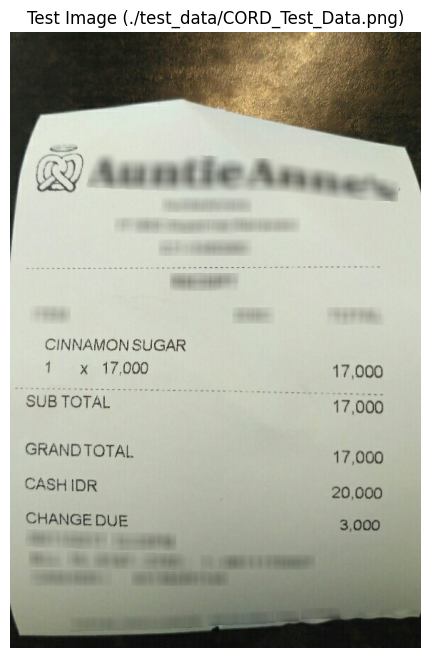

In [6]:
# 입력: 로컬 도면 이미지 (CORD 데이터셋 대신)
IMAGE_PATH = "./test_data/CORD_Test_Data.png"
image = Image.open(IMAGE_PATH).convert("RGB")
ground_truth = None   # 로컬 이미지는 정답 레이블(GT) 없음

print(f"이미지: {IMAGE_PATH}")
print(f"크기: {image.size}  모드: {image.mode}")

plt.figure(figsize=(6, 8))
plt.imshow(image)
plt.axis("off")
plt.title(f"Test Image ({IMAGE_PATH})")
plt.show()

### 로컬 캐시 위치

`load_dataset` 최초 실행 시 HuggingFace Hub에서 파인튜닝 모델(영수증 파싱 CORD)가 자동 다운로드되며, 이후 호출은 캐시에서 즉시 로드됩니다.

```
~/.cache/huggingface/datasets/naver-clova-ix___cord-v2/
└── default/0.0.0/7f0115a4.../
    ├── cord-v2-train-00000-of-00002.arrow   ← train (절반)
    ├── cord-v2-train-00001-of-00002.arrow   ← train (절반)
    ├── cord-v2-validation.arrow             ← validation
    ├── cord-v2-test.arrow                   ← test
    └── dataset_info.json                    ← 메타 정보
```

| 항목   | 내용                                        |
|--------|---------------------------------------------|
| 총 용량 | 2.2 GB                                     |
| 포맷   | `.arrow` (Apache Arrow — 빠른 컬럼형 포맷)  |

> **🔹 역할** — 모델 config 전체 출력

In [6]:
print(model.config)

VisionEncoderDecoderConfig {
  "architectures": [
    "VisionEncoderDecoderModel"
  ],
  "decoder": {
    "activation_dropout": 0.0,
    "activation_function": "gelu",
    "add_cross_attention": true,
    "add_final_layer_norm": true,
    "attention_dropout": 0.0,
    "classifier_dropout": 0.0,
    "d_model": 1024,
    "decoder_attention_heads": 16,
    "decoder_ffn_dim": 4096,
    "decoder_layerdrop": 0.0,
    "decoder_layers": 4,
    "dropout": 0.1,
    "dtype": "float32",
    "encoder_attention_heads": 16,
    "encoder_ffn_dim": 4096,
    "encoder_layerdrop": 0.0,
    "encoder_layers": 12,
    "init_std": 0.02,
    "is_decoder": true,
    "is_encoder_decoder": false,
    "max_position_embeddings": 768,
    "model_type": "mbart",
    "num_hidden_layers": 12,
    "scale_embedding": true,
    "use_cache": true,
    "vocab_size": 57580
  },
  "dtype": "float32",
  "encoder": {
    "attention_probs_dropout_prob": 0.0,
    "depths": [
      2,
      2,
      14,
      2
    ],
    "drop_p

> **🔹 역할** — 토크나이저에 등록된 특수 토큰 목록 확인

In [7]:
# 등록된 특수 토큰 목록 확인
# <s_cord-v2> ->  태스크 이름 = 학습에 사용한 데이터셋 이름
print(processor.tokenizer.all_special_tokens)

['<s>', '</s>', '<unk>', '<pad>', '<mask>', '<s_cord-v2>']


### 특수 토큰(Special Tokens) 설명

`processor.tokenizer.all_special_tokens` 출력:

```python
['<s>', '</s>', '<unk>', '<pad>', '<mask>', '<s_cord-v2>']
```

Donut 디코더(mBART 토크나이저)에 등록된 특수 토큰 목록입니다. 각각의 역할은 다음과 같습니다.

| 토큰 | 이름 | 역할 |
|------|------|------|
| `<s>` | BOS (Begin Of Sequence) | 시퀀스 **시작**을 알리는 토큰. BART 계열의 기본 시작 토큰 |
| `</s>` | EOS (End Of Sequence) | 시퀀스 **끝**을 알리는 토큰. 생성(generation) 시 이 토큰이 나오면 디코딩을 멈춤 |
| `<unk>` | Unknown | 어휘집(vocab)에 **없는 단어**를 대체하는 토큰. 추론 시 `bad_words_ids`로 생성을 금지함 |
| `<pad>` | Padding | 배치 안에서 길이를 맞추기 위해 짧은 시퀀스를 **채우는** 토큰. 학습 시 이 위치의 loss는 무시됨(`-100`) |
| `<mask>` | Mask | (m)BART 사전학습 때 쓰던 **마스킹** 토큰. Donut 파인튜닝에서는 거의 사용 안 함 |
| `<s_cord-v2>` | Task prompt / 시작 토큰 | **추가로 등록된 커스텀 토큰**. CORD-v2(영수증) 태스크 전용. 디코더가 "지금부터 영수증 JSON을 토큰으로 뱉어라"라고 인식하게 하는 신호 |

#### 핵심 포인트

- 앞의 5개(`<s> </s> <unk> <pad> <mask>`)는 **mBART 토크나이저에 원래 들어있던 표준 special token**입니다.
- 마지막 `<s_cord-v2>` 만 **Donut이 태스크용으로 새로 추가한 토큰**입니다. 이 토큰은
  - 토크나이저에 `add_special_tokens`로 등록되고,
  - 디코더 임베딩 크기를 `resize` 하며,
  - 이 토큰의 ID가 `decoder_start_token_id`로 지정됩니다.

#### 실제 시퀀스에서의 흐름

학습 타깃과 생성 결과는 다음과 같이 구성됩니다.

```
<s_cord-v2>  <s_total>12500</s_total> ...  </s>
   ↑                                        ↑
task_prompt(=디코더 시작 토큰)        eos_token(끝)
+ json2token(정답 JSON)
```

즉 디코더는 `<s_cord-v2>` 로 시작 → JSON을 XML 스타일 토큰으로 생성 → `</s>` 로 종료합니다.

> ⚠️ 다른 태스크(예: 도면 데이터)로 바꾸려면 `task_prompt`를 `<s_cord-v2>`가 아닌 새 토큰으로 교체하고 토크나이저에 등록해야 합니다. 안 그러면 모델이 시작 토큰을 인식하지 못합니다.


> **🔹 역할** — 태스크 토큰으로 이미지 추론을 수행해 원시 출력 시퀀스 생성·정제

In [ ]:
# task_prompt: 모델에게 수행할 태스크를 지정하는 특수 토큰
# <s_cord-v2>는 영수증 파싱 태스크를 의미하며, 디코더의 첫 번째 입력으로 사용됨
task_prompt = "<s_cord-v2>"

# 디코더의 첫 입력으로 쓸 task_prompt("<s_cord-v2>")를 토크나이저로 숫자 ID로 변환합니다.
# add_special_tokens=False이므로 <s>, </s> 같은 토큰은 따로 추가하지 않습니다.
decoder_input_ids = processor.tokenizer(
    task_prompt, add_special_tokens=False, return_tensors="pt"
).input_ids.to(device)

print('decoder_input_ids', decoder_input_ids)

# processor: 이미지를 모델 입력 크기(1280×960)로 리사이즈 후 [-1, 1] 범위로 정규화
pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

with torch.no_grad():  # 추론 시 gradient 계산 생략 → 메모리 절약
    outputs = model.generate(
        pixel_values,
        decoder_input_ids=decoder_input_ids,
        max_length=model.decoder.config.max_position_embeddings,  # 최대 시퀀스 길이
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,            # EOS 토큰 도달 시 생성 중단
        use_cache=True,                                            # KV-cache로 디코딩 속도 향상
        bad_words_ids=[[processor.tokenizer.unk_token_id]],       # UNK 토큰 생성 금지
        return_dict_in_generate=True,
    )

# 생성된 토큰 ID → 문자열로 디코딩
sequence = processor.batch_decode(outputs.sequences)[0]

# 특수 토큰(EOS, PAD) 제거 
sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(
    processor.tokenizer.pad_token, ""
)
# 첫 번째 태스크 토큰(<s_cord-v2> 등)을 정규식으로 찾아서 제거합니다.
# 예: "<s_cord-v2>...실제내용..." → "...실제내용..."
sequence = re.sub(r"<.*?>", "", sequence, count=1).strip()
print("Raw output:", sequence)

decoder_input_ids tensor([[57579]], device='cuda:0')
Raw output: <s_menu> <s_nm> CINNAMON SUGAR </s_nm> <s_unitprice> 17,000 </s_unitprice> <s_cnt> 1 x </s_cnt> <s_price> 17,000 </s_price> </s_menu> <s_sub_total> <s_subtotal_price> 17,000 </s_subtotal_price> </s_sub_total> <s_total> <s_total_price> 17,000 </s_total_price> <s_cashprice> 20,000 </s_cashprice> <s_changeprice> 3,000 </s_changeprice> </s_total>


## 추론 (Inference)

### 정규식 패턴 `re.sub(r"<.*?>", "", sequence, count=1)`

Donut 출력의 맨 앞 태스크 토큰 `<s_cord-v2>`를 제거하는 코드입니다.

#### 패턴 각 문자 의미

| 문자 | 의미 |
|------|------|
| `r"..."` | raw string — 백슬래시를 특수문자로 처리하지 않음 |
| `<` | `<` 문자 그대로 매칭 |
| `.` | 어떤 문자든 1개 |
| `*` | 앞 문자(`.`)가 0개 이상 반복 |
| `?` | 최소 매칭 — 가능한 짧게 매칭 |
| `>` | `>` 문자 그대로 매칭 |

#### `*` vs `*?` 차이 (최대 매칭 vs 최소 매칭)

```python
문자열 = "<s_menu><s_nm>치킨</s_nm>"

r"<.*>"   # 최대 매칭 → <s_menu><s_nm>치킨</s_nm> 전체를 하나로 잡음
r"<.*?>"  # 최소 매칭 → <s_menu> 만 잡음 (첫 > 에서 멈춤)
```

#### 실제 동작

```python
re.sub(r"<.*?>", "", "<s_cord-v2><s_menu>치킨</s_menu>", count=1)
# count=1 → 맨 앞 태그 1개만 제거
# → "<s_menu>치킨</s_menu>"
```

> **🔹 역할** — token2json 함수로 XML형 토큰 시퀀스를 dict로 파싱

In [12]:
def token2json(tokens, is_inner_value=False):
    """XML-like 토큰 시퀀스를 Python dict로 변환
    예: <s_total>12500</s_total> → {"total": "12500"}
    중첩 구조(dict 안의 dict)도 재귀적으로 처리
    """
    output = {}
    while tokens:
        start_token = re.search(r"<s_(.*?)>", tokens)
        if not start_token:
            break
        key = start_token.group(1)
        end_token = re.search(rf"</s_{key}>", tokens)
        value = tokens[start_token.end(): end_token.start() if end_token else len(tokens)]
        value = value.strip()
        if re.search(r"<s_", value):          # 중첩 태그가 있으면 재귀 파싱
            value = token2json(value, is_inner_value=True)
            if value:
                output[key] = value
        else:
            output[key] = value               # 리프 노드: 문자열 값 저장
        tokens = tokens[end_token.end():].strip() if end_token else ""
    return output

result = token2json(sequence)
print("Parsed result:")
print(json.dumps(result, indent=2, ensure_ascii=False))

Parsed result:
{
  "menu": {
    "nm": "CINNAMON SUGAR",
    "unitprice": "17,000",
    "cnt": "1 x",
    "price": "17,000"
  },
  "sub_total": {
    "subtotal_price": "17,000"
  },
  "total": {
    "total_price": "17,000",
    "cashprice": "20,000",
    "changeprice": "3,000"
  }
}


### `token2json` 함수

Donut이 출력한 XML 형태의 토큰 시퀀스를 Python `dict`로 변환하는 함수입니다.

#### 입력 / 출력

```
입력 (Raw output 문자열)
<s_menu><s_nm>치킨</s_nm><s_price>12000</s_price></s_menu><s_total><s_total_price>12000</s_total_price></s_total>

출력 (Python dict)
{
  "menu": {
    "nm": "치킨",
    "price": "12000"
  },
  "total": {
    "total_price": "12000"
  }
}
```

#### 동작 흐름

```
1. <s_키> 태그 탐색        re.search(r"<s_(.*?)>", tokens)
        ↓
2. </s_키> 닫힘 태그 탐색  re.search(rf"</s_{key}>", tokens)
        ↓
3. 태그 사이 값 추출
        ↓
4. 값 안에 <s_> 태그가 있으면?
   ├── YES → 재귀 호출 (중첩 dict 생성)
   └── NO  → 문자열 값으로 저장
        ↓
5. 닫힘 태그 이후 문자열로 이동 후 반복
```

#### 재귀 처리 예시

```python
# 중첩 태그 → 재귀적으로 dict 안의 dict 생성
"<s_menu><s_nm>치킨</s_nm></s_menu>"
→ {"menu": {"nm": "치킨"}}   # menu 값 파싱 시 재귀 호출

# 리프 노드 → 문자열로 저장
"<s_nm>치킨</s_nm>"
→ {"nm": "치킨"}
```

> **🔹 역할** — 입력 이미지와 파싱 결과(JSON)를 나란히 시각화

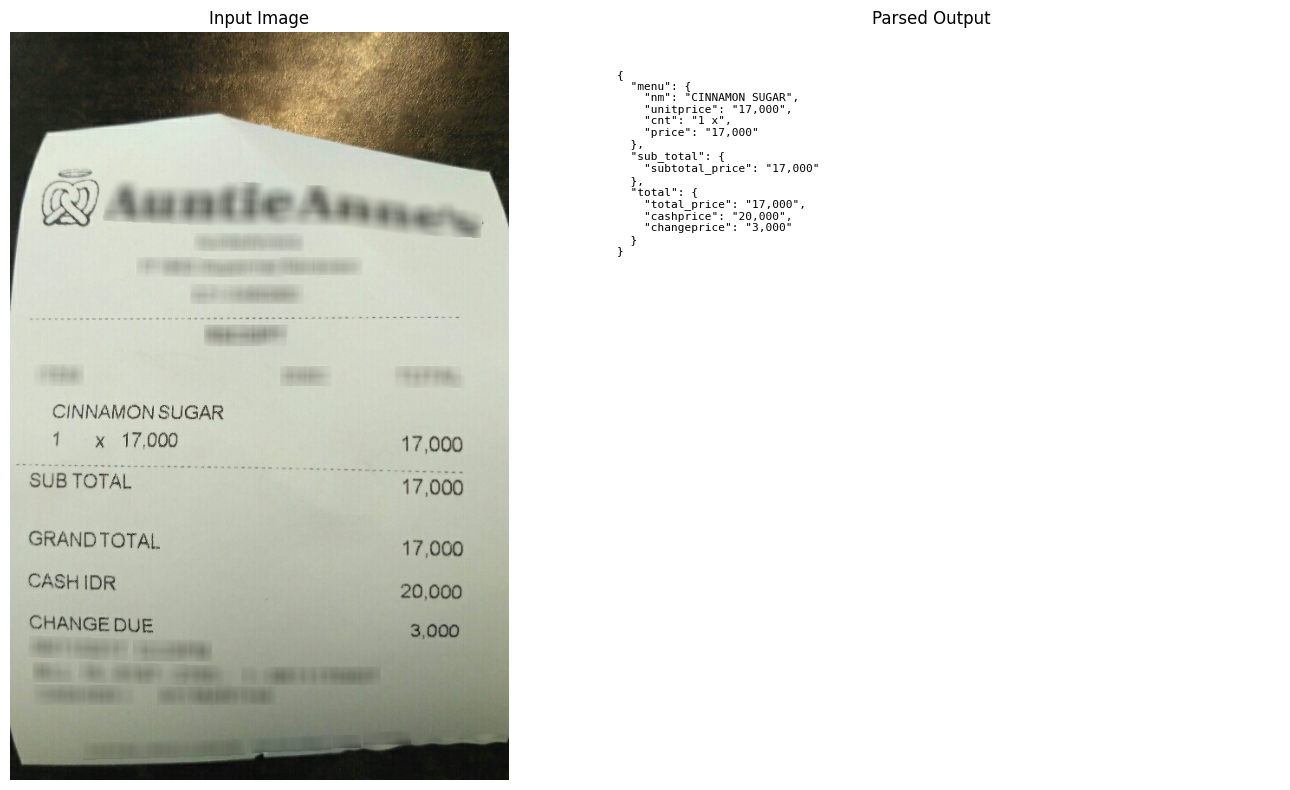

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].imshow(image)
axes[0].axis("off")
axes[0].set_title("Input Image")

axes[1].axis("off")
axes[1].set_title("Parsed Output")
axes[1].text(
    0.05, 0.95,
    json.dumps(result, indent=2, ensure_ascii=False),
    transform=axes[1].transAxes,
    fontsize=8,
    verticalalignment="top",
    fontfamily="monospace"
)

plt.tight_layout()
plt.show()